In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split


In [39]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Ishika grover\Downloads\statlog+german+credit+data\german.data-numeric",
    header=None,
    sep="\s+"   # handles multiple spaces correctly
)



In [40]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2
5,4,36,2,91,5,3,3,4,4,35,...,0,0,1,0,0,0,0,1,0,1
6,4,24,2,28,3,5,3,4,2,53,...,0,0,1,0,0,1,0,0,1,1
7,2,36,2,69,1,3,3,2,3,35,...,0,1,1,0,1,0,0,0,0,1
8,4,12,2,31,4,4,1,4,1,61,...,0,0,1,0,0,1,0,1,0,1
9,2,30,4,52,1,1,4,2,3,28,...,1,0,1,0,0,1,0,0,0,2


In [41]:
print(df.shape)

(1000, 25)


In [42]:
print(df.isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
dtype: int64


In [43]:
# Encode Categorical Variables
df[24] = df[24].replace({1: 1, 2: 0})

In [44]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [45]:
# Normalize / Standardize Numerical Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define model
model = Sequential()

# Hidden Layer 1
model.add(Dense(32, activation='relu', input_shape=(X_scaled.shape[1],)))

# Hidden Layer 2
model.add(Dense(16, activation='relu'))

# Output Layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

# Model Summary
model.summary()

D:\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compile the model
model.compile(
    optimizer='adam',               # You can also use 'sgd' if you prefer
    loss='binary_crossentropy',     # Binary classification loss
    metrics=['accuracy']            # Track accuracy during training
)

In [52]:
# Split the dataset into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [53]:
# Train the model
history = model.fit(
    X_train, y_train,               # Training data
    validation_data=(X_val, y_val),# Validation data
    epochs=50,                      # Number of training epochs
    batch_size=16,                  # Batch size
    verbose=1                       # Display training progress
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6938 - loss: 0.6039 - val_accuracy: 0.7150 - val_loss: 0.5724
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7212 - loss: 0.5329 - val_accuracy: 0.7300 - val_loss: 0.5408
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7437 - loss: 0.5012 - val_accuracy: 0.7250 - val_loss: 0.5275
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7650 - loss: 0.4806 - val_accuracy: 0.7300 - val_loss: 0.5125
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7812 - loss: 0.4691 - val_accuracy: 0.7450 - val_loss: 0.5020
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7912 - loss: 0.4562 - val_accuracy: 0.7650 - val_loss: 0.5001
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7925 - loss: 0.4468 - val_accuracy: 0.7650 - val_loss: 0.4973
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7975 - loss: 0.4383 - val_accuracy: 0.7600 - val_

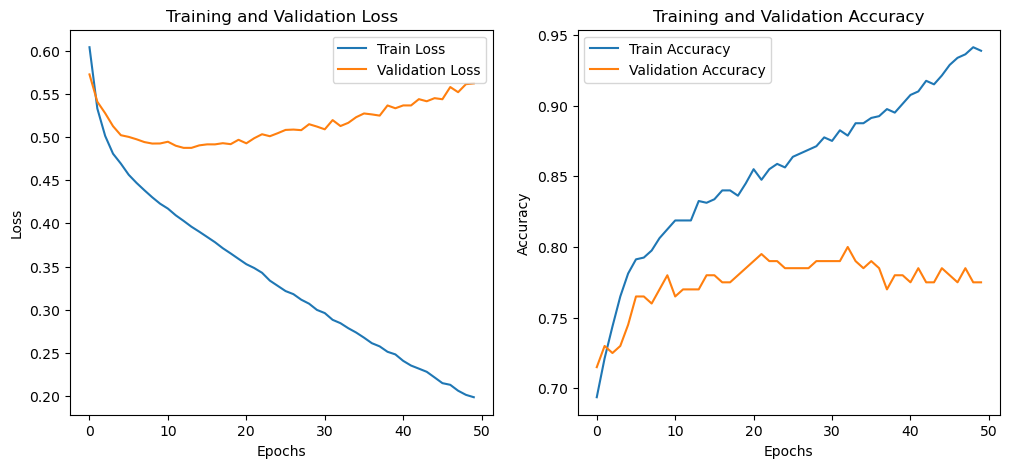

In [54]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [55]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict on validation data
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)   # Convert probabilities to 0 or 1

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

# Precision
precision = precision_score(y_val, y_pred)
print("Precision:", precision)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 
Confusion Matrix:
 [[ 30  29]
 [ 16 125]]
Accuracy: 0.775
Precision: 0.8116883116883117
Recall: 0.8865248226950354
F1 Score: 0.847457627118644
